## Spare Apertures & Propagation

This tutorial is designed to show some new functionality from (abcdLux)[https://github.com/LouisDesdoigts/abcdLux]. This new library is a more powerful low-level propagator library built for dLux. It has a lot extra functionality and including sparse aperture support, explicit propagation kernel caching, and a fully generalised treatment of Fresnel propagation using Linear Canonical Transforms. In this tutorial we will be examining how we can create a custom propagation function that can leverage the sparsity of an aperture to propagate an PSF much faster than the full aperture!

In [1]:
## COLLAPSE: Imports
# Basic imports
import jax.numpy as np
import jax.random as jr
from jax import vmap, jit

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
import matplotlib.pyplot as plt
import matplotlib as mpl

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 90

# Nan friendly colormapping
inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

We are going to use the KECK 17-hole mask, as it has lots of small holes giving us a very sparse aperture to work with. We can define this aperture by the aperture hole centers, and use the `dlu.sparse_aperture` function to generate the aperture and a zernike basis for it.

In [2]:
# Aperture hole coordinates
cens = np.array(
    [
        [0.821457, 2.34684],
        [-2.34960, 1.49034],
        [-2.54456, 2.55259],
        [1.64392, 3.04681],
        [2.73751, -0.321102],
        [1.38503, -3.31443],
        [-3.19337, -1.68413],
        [3.05126, 0.560011],
        [-2.76083, 1.14035],
        [3.02995, -1.91449],
        [0.117786, 3.59025],
        [-0.802156, 3.42140],
        [-1.47228, -3.28982],
        [-1.95968, -0.634178],
        [0.876319, -3.13328],
        [2.01253, -1.55220],
        [-2.07847, -2.57755],
    ]
)

Great now lets just build a regular optical system and propagate a PSF through it to see what we are working with.

In [3]:
# Generate the full aperture
wf_npix = 1024
diam = 8.2
js = np.arange(1, 22)
aper, basis = dlu.sparse_aperture(wf_npix, diam, cens, 0.45, zernike_nolls=js)
coeffs = 1e-9 * jr.normal(jr.key(0), basis.shape[:2])

# Observational wavelength
wavel = 1e-6
lamd = wavel / diam

# PSF Parameters
psf_pixel_scale = dlu.rad2arcsec(lamd) / 2.5
psf_npix = 128

# Generate the optical system
optics = dl.AngularOpticalSystem(
    wf_npixels=wf_npix,
    diameter=diam,
    layers=[
        ("aper", dl.TransmissiveLayer(aper, normalise=True)),
        ("wfe", dl.BasisLayer(basis, coeffs)),
    ],
    psf_npixels=psf_npix,
    psf_pixel_scale=psf_pixel_scale,
)

# Propagate the PSF and get the power spectrum
psf = optics.propagate(wavel)
ps = np.fft.fftshift(np.fft.fft2(psf))

Now lets take a look at our aperture, PSF, and power spectrum to see what we are working with

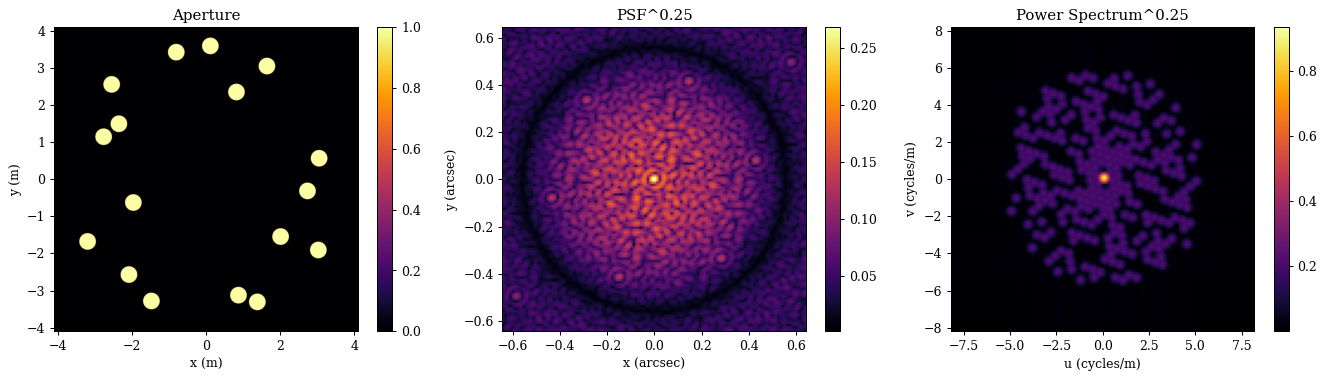

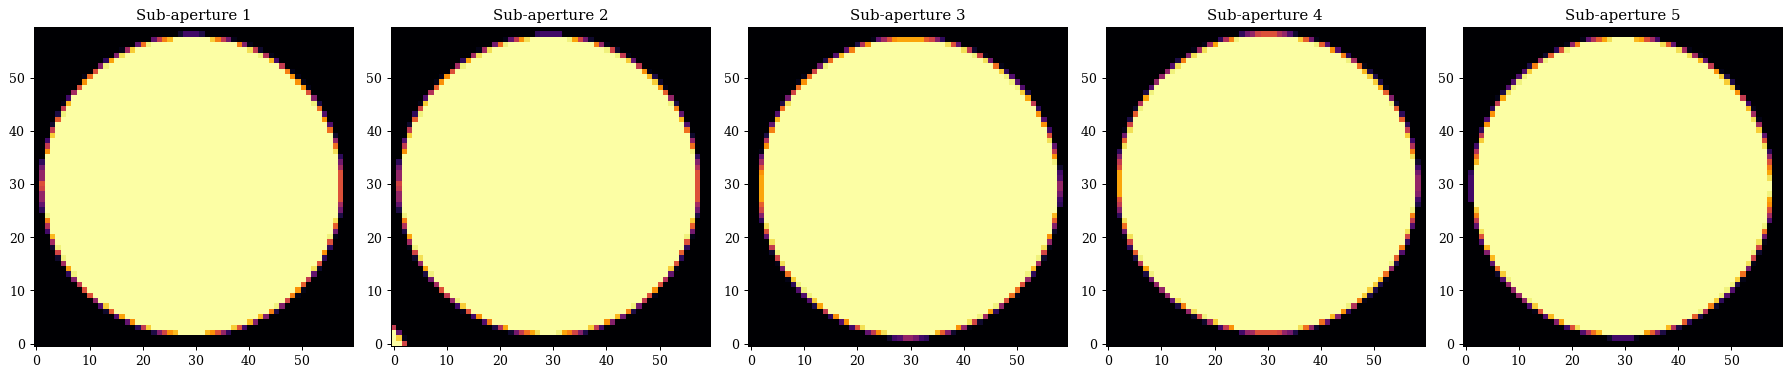

In [4]:
## COLLAPSE: Plotting
# Plotting function
def cartesian_to_array(xy, npix, diameter):
    """Convert cartesian coordinates to array indices."""
    pixel_scale = diameter / npix
    return np.round(xy / pixel_scale + npix // 2).astype(int)

aper_ext = dlu.imshow_extent(diam)
psf_ext = dlu.imshow_extent(optics.fov)
ps_ext = dlu.imshow_extent(2*diam)

plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 3, 1)
im = ax.imshow(aper, extent=aper_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Aperture", xlabel="x (m)", ylabel="y (m)")

ax = plt.subplot(1, 3, 2)
im = ax.imshow(psf**0.25, extent=psf_ext)
plt.colorbar(im, ax=ax)
ax.set(title="PSF^0.25", xlabel="x (arcsec)", ylabel="y (arcsec)")

ax = plt.subplot(1, 3, 3)
im = ax.imshow(np.abs(ps) ** 0.5, extent=ps_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Power Spectrum^0.25", xlabel="u (cycles/m)", ylabel="v (cycles/m)")

plt.tight_layout()
plt.show()

s = 30
inds = vmap(cartesian_to_array, (0, None, None))(cens, wf_npix, diam)

plt.figure(figsize=(20, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.title(f"Sub-aperture {i+1}")
    cj, ci = inds[i]
    plt.imshow(aper[ci - s : ci + s, cj - s : cj + s])
plt.tight_layout()
plt.show()

Okay cool, as we can see our aperture is very space, and each sub-aperture is only represented by ~60x60 pixels, which is not a very high resolution! Now lets turn to sparse propagation with the new `abcdLux` module. It has a different syntax which we aren't going to cover here (you can check out the new library if you are interested), we will instead just use it to propagate the sparse aperture and see how it compares to the regular propagation we just did.

An important thing to note is that are also using a 128x128 sized array to represent the sub-aperture and zernike basis - which is more than 4x the amount of pixels we have across each sub-aperture in the full aperture. Despite this much higher resolution, as we will see this method will be _much_ faster than the regular propagation method, which is pretty great! We also only need to use a _single_ sub-aperture and a _single_ zernike basis to represent the entire wavefront as `abcdLux` allows us to define the input and output coordinates of our wavefronts, so we can propagate this single sub-aperture from each hole position in the aperture and interfere the complex wavefronts at the output!

In [5]:
import abcdLux

# Generate the sparse aperture - we only need a single one!
subap_npix = 128
subap_diam = 0.45
sub_aper, subap_basis = dlu.circular_aperture(subap_npix, subap_diam, zernike_nolls=js)
subap_coeffs = 1e-9 * jr.normal(jr.key(0), (len(cens), len(subap_basis)))

# Normalised subaperture amplitude
subaper_ampl = sub_aper / (np.linalg.norm(np.sqrt(len(cens)) * sub_aper))

# Input coordinates
x_in = dlu.nd_coords(subap_npix, subap_diam / subap_npix)
y_in = dlu.nd_coords(subap_npix, subap_diam / subap_npix)

# Output coordinates
x_out = dlu.nd_coords(psf_npix, dlu.arcsec2rad(psf_pixel_scale))
y_out = dlu.nd_coords(psf_npix, dlu.arcsec2rad(psf_pixel_scale))

# Function to build the OPD over each subaperture
build_opd = vmap(lambda coeffs: dlu.eval_basis(subap_basis, coeffs))

# Basic propagation function for a single subaperture
subap_prop_fn = vmap(
    lambda cen, opd: abcdLux.fraunhofer_prop(
        u_pupil=subaper_ampl * np.exp(1j * dlu.opd2phase(opd, wavel)),
        spec_in=(x_in + cen[0], y_in + cen[1]),
        spec_out=(x_out, y_out),
        lam=wavel,
        f=1,  # Gives pixel scale in radians
    )
)

# Overall propagation function for the sparse aperture
prop_fn = lambda cen, coeffs: np.abs(subap_prop_fn(cen, build_opd(coeffs)).sum(0)) ** 2

# Propagate the PSF and get the power spectrum
psf = prop_fn(cens, subap_coeffs)
ps = np.fft.fftshift(np.fft.fft2(psf))

Now lets examine the outputs to make sure everything looks correct.

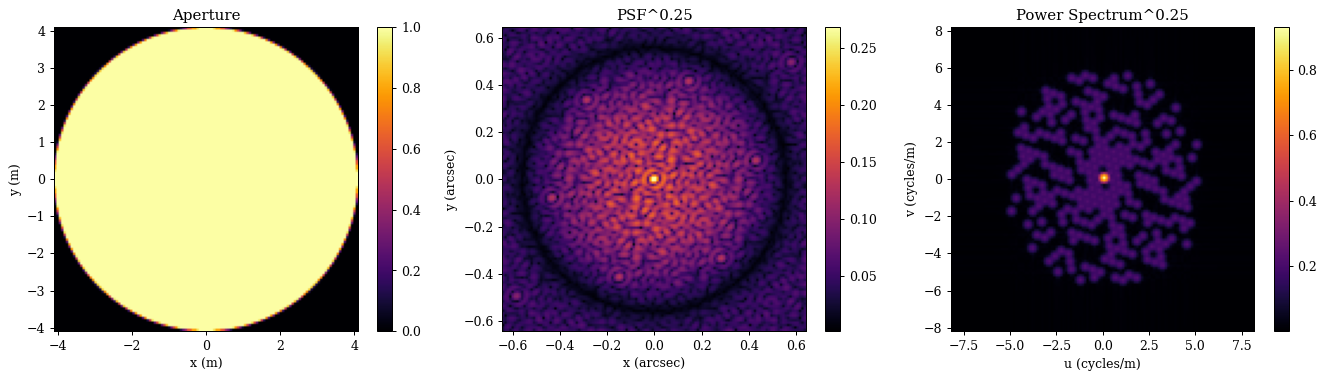

In [6]:
## COLLAPSE: Plotting
plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 3, 1)
im = ax.imshow(sub_aper, extent=aper_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Aperture", xlabel="x (m)", ylabel="y (m)")

ax = plt.subplot(1, 3, 2)
im = ax.imshow(psf**0.25, extent=psf_ext)
plt.colorbar(im, ax=ax)
ax.set(title="PSF^0.25", xlabel="x (arcsec)", ylabel="y (arcsec)")

ax = plt.subplot(1, 3, 3)
im = ax.imshow(np.abs(ps) ** 0.5, extent=ps_ext)
plt.colorbar(im, ax=ax)
ax.set(title="Power Spectrum^0.25", xlabel="u (cycles/m)", ylabel="v (cycles/m)")

plt.tight_layout()
plt.show()

Awesome, everything works! Now lets do a little benchmark to see how much faster the sparse propagation method is compared to the regular method. We will be using `timeit` to do this, and we will be running each method 10 times to get a good estimate of the average runtime. Its important to note that when profiling with jax, we need to use the `.block_until_ready()` method to ensure that all computations are finished before we stop the timer.

In [7]:
# Define the dense and sparse propagation functions with JIT compilation
dense_fn = jit(lambda wl: optics.propagate(wl))
sparse_fn = jit(lambda coeffs: prop_fn(cens, coeffs))

# Compile each of them
_ = dense_fn(wavel)
_ = sparse_fn(subap_coeffs)

Now we can time each method using `timeit`.

In [8]:
%%timeit
_ = dense_fn(wavel).block_until_ready()

722 ms ± 25.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [9]:
%%timeit
_ = sparse_fn(subap_coeffs).block_until_ready()

3.9 ms ± 58.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


Wow, as we can see the dense propagator take ~700ms and the sparse propagator takes ~4ms, which is a speedup of over 150x! This is a huge speedup and really shows the power of leveraging the sparsity of the aperture to speed up our computations. This is especially important for applications like wavefront sensing and control, where we need to be able to propagate wavefronts very quickly in order to make real-time corrections to the wavefront.

`abcdLux` also gives us ways to accelerate this computation even more by caching the propagation kernels! We wont cover it here, but if you are interested in learning more about that, check out the `abcdLux` library!